In [2]:
import pandas as pd
import numpy as np
 
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [3]:
diamonds = pd.read_csv("files/Diamonds Prices2022.csv")
 
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
X = diamonds[["carat"]]
y = diamonds["price"]

In [5]:
model = sm.OLS(y, X).fit() #summary()

In [6]:
X = sm.add_constant(diamonds["carat"])
y = diamonds["price"]
 
model = sm.OLS(y, X).fit()
 
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:06:42   Log-Likelihood:            -4.7276e+05
No. Observations:               53943   AIC:                         9.455e+05
Df Residuals:                   53941   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3950     13.055   -172.840      0.000   -2281.983   -2230.807
carat       7756.4362     14.066    551.423      0.000    7728.866    7784.006
==============================================================================
Omnibus:                    14027.005   Durbin-Watson:                   0.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           153060.389
Skew:                           0.939   Prob(JB):                         0.00
Kurtosis:                      11.036   Cond. No.                         3.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
lr = LinearRegression().fit(X, y)
 
print(f"Intercept: {lr.intercept_}")
print(f"Coefficients: {lr.coef_}")

Intercept: -2256.3950475377032
Coefficients: [   0.         7756.43615951]


In [8]:
carats = sm.add_constant(pd.DataFrame({"carat" :[.5, 1, 1.5, 2, 2.5]}))
model.predict(carats)

0     1621.823032
1     5500.041112
2     9378.259192
3    13256.477271
4    17134.695351
dtype: float64

In [9]:
new_diamonds = pd.DataFrame({"carat": [0, .1, .3, .5, 1, 2, 3, 5]})

<Axes: ylabel='None'>

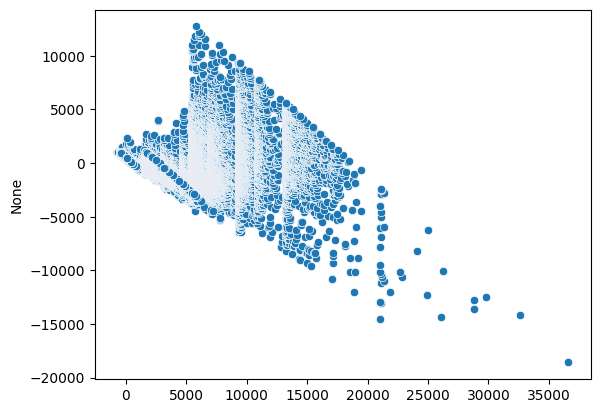

In [11]:
import seaborn as sns
 
sns.scatterplot(x=model.predict(), y=model.resid)

In [12]:
residuals = pd.DataFrame (
    {
        "Carat": diamonds["carat"],
        "Price": diamonds["price"],
        "Predicted Price": model.predict(),
        "Residual":model.resid
    }
)
 

In [13]:
residuals.describe()

,Carat,Price,Predicted Price,Residual
count,53943.000000,53943.000000,53943.000000,5.394300e+04
mean,0.797935,3932.734294,3932.734294,-1.436443e-11
std,0.473999,3989.338447,3676.539517,1.548508e+03
min,0.200000,326.000000,-705.107816,-1.858535e+04
25%,0.400000,950.000000,846.179416,-8.047440e+02
50%,0.700000,2401.000000,3173.110264,-1.905069e+01
75%,1.040000,5324.000000,5810.298558,5.374642e+02
max,5.010000,18823.000000,36603.350112,1.273170e+04


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import statsmodels.api as sm
from scipy import stats
 
np.random.seed(7)

In [15]:
ad_spend_k = np.array([5, 7, 8, 10, 12, 13, 15, 18, 20, 22, 25, 28, 30, 35, 40], dtype=float)
 
# Pardavimai su triukšmu: bazė + 1.8 * biudžetas + atsitiktinis triukšmas
noise = np.random.normal(loc=0, scale=4, size=ad_spend_k.size)
sales_k = 20 + 1.8 * ad_spend_k + noise
 
df = pd.DataFrame({"ad_spend_k": ad_spend_k, "sales_k": sales_k})
df.head()

,ad_spend_k,sales_k
0,5.0,35.762103
1,7.0,30.736251
2,8.0,34.531281
3,10.0,39.630065
4,12.0,38.444308


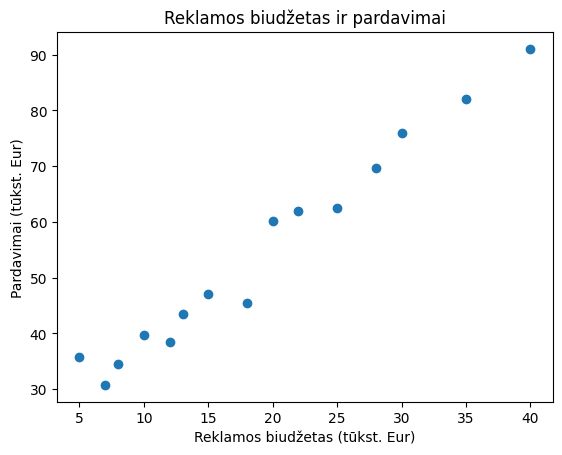

In [16]:
plt.figure()
plt.scatter(df["ad_spend_k"], df["sales_k"])
plt.xlabel("Reklamos biudžetas (tūkst. Eur)")
plt.ylabel("Pardavimai (tūkst. Eur)")
plt.title("Reklamos biudžetas ir pardavimai")
plt.show()

In [17]:
X = sm.add_constant(df["ad_spend_k"])   # pridedamas intercept
y = df["sales_k"]
 
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                sales_k   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     444.4
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.95e-11
Time:                        15:25:03   Log-Likelihood:                -38.134
No. Observations:                  15   AIC:                             80.27
Df Residuals:                      13   BIC:                             81.68
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.0018      1.805     11.633      0.000      17.102      24.902
ad_spend_k     1.7471      0.083     21.080      0.000       1.568       1.926
==============================================================================
Omnibus:                        1.193   Durbin-Watson:                   2.318
Prob(Omnibus):                  0.551   Jarque-Bera (JB):                0.177
Skew:                          -0.224   Prob(JB):                        0.915
Kurtosis:                       3.288   Cond. No.                         46.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
params = model.params
conf = model.conf_int()
pd.DataFrame({
    "coef": params,
    "ci_low": conf[0],
    "ci_high": conf[1]
})

,coef,ci_low,ci_high
const,21.001803,17.101517,24.902089
ad_spend_k,1.747056,1.568011,1.926102


In [19]:
new_ad_spend = pd.DataFrame({"ad_spend_k": [6, 14, 26, 38]})
new_X = sm.add_constant(new_ad_spend)
 
pred = model.get_prediction(new_X).summary_frame(alpha=0.05)
result_pred = pd.concat([new_ad_spend, pred], axis=1)
result_pred

,ad_spend_k,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6,31.484142,1.387131,28.487426,34.480857,23.744631,39.223653
1,14,45.460593,0.955547,43.396259,47.524928,38.032188,52.888999
2,26,66.425271,1.022227,64.216883,68.633658,58.955552,73.894990
3,38,87.389948,1.776230,83.552636,91.227260,79.287807,95.492089


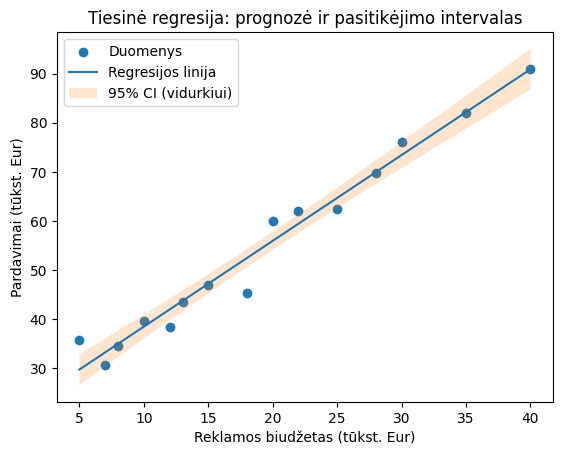

In [20]:
# Prognozė visame x diapazone
x_grid = np.linspace(df["ad_spend_k"].min(), df["ad_spend_k"].max(), 200)
grid_X = sm.add_constant(pd.Series(x_grid, name="ad_spend_k"))
grid_pred = model.get_prediction(grid_X).summary_frame(alpha=0.05)
 
plt.figure()
plt.scatter(df["ad_spend_k"], df["sales_k"], label="Duomenys")
plt.plot(x_grid, grid_pred["mean"], label="Regresijos linija")
plt.fill_between(x_grid, grid_pred["mean_ci_lower"], grid_pred["mean_ci_upper"], alpha=0.2, label="95% CI (vidurkiui)")
plt.xlabel("Reklamos biudžetas (tūkst. Eur)")
plt.ylabel("Pardavimai (tūkst. Eur)")
plt.title("Tiesinė regresija: prognozė ir pasitikėjimo intervalas")
plt.legend()
plt.show()

In [21]:
model.rsquared

np.float64(0.9715765393721252)

In [22]:
alpha = 0.05
p_slope = model.pvalues["ad_spend_k"]
t_slope = model.tvalues["ad_spend_k"]
 
alpha, t_slope, p_slope

(0.05, np.float64(21.080053521851067), np.float64(1.9540826833866177e-11))

In [23]:
conclusion = "H0 atmetama: nuolydis statistiškai reikšmingas." if p_slope < alpha else "Nėra pagrindo atmesti H0: nuolydis statistiškai nereikšmingas."
conclusion

'H0 atmetama: nuolydis statistiškai reikšmingas.'

In [24]:
df["y_hat"] = model.fittedvalues
df["residual"] = model.resid
df.head()

,ad_spend_k,sales_k,y_hat,residual
0,5.0,35.762103,29.737085,6.025017
1,7.0,30.736251,33.231198,-2.494948
2,8.0,34.531281,34.978255,-0.446974
3,10.0,39.630065,38.472368,1.157698
4,12.0,38.444308,41.966480,-3.522173


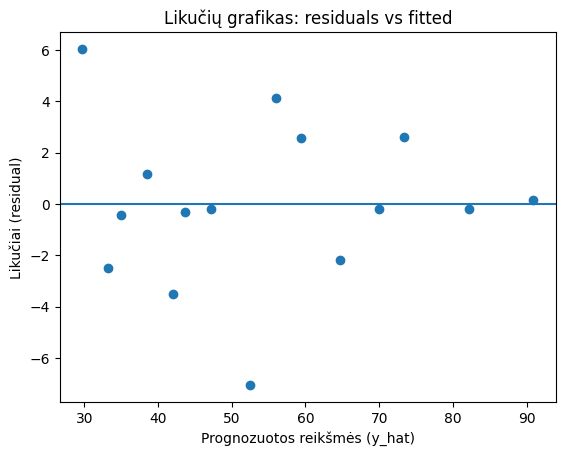

In [25]:
plt.figure()
plt.scatter(df["y_hat"], df["residual"])
plt.axhline(0)
plt.xlabel("Prognozuotos reikšmės (y_hat)")
plt.ylabel("Likučiai (residual)")
plt.title("Likučių grafikas: residuals vs fitted")
plt.show()

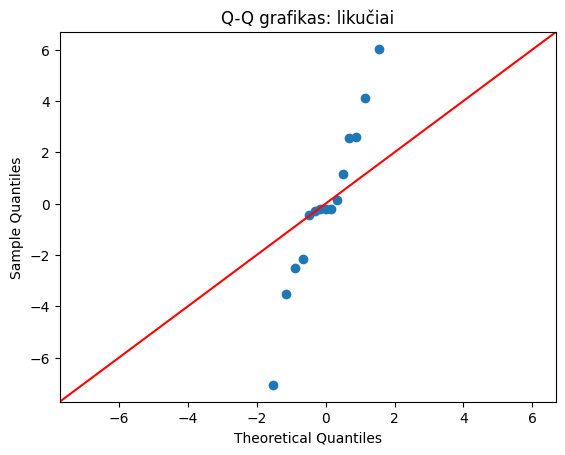

In [26]:
sm.qqplot(df["residual"], line="45")
plt.title("Q-Q grafikas: likučiai")
plt.show()